# Nike India Sales: Channels, Discounts & Margins



Name : Sreeram.K.U.



Batch : ML-DAF50


Date : 30/09/2026

Dataset Link : https://www.kaggle.com/datasets/nayakganesh007/nike-sales-uncleaned-dataset?utm_source=chatgpt.com


# Introduction
Every retail brand aims for high sales, but moving large volumes doesn't guarantee healthy profits. When Nike runs major seasonal discounts across India, order numbers shoot up—yet actual profits can quietly shrink or even slip into losses. On top of that, raw sales logs are rarely clean. Many transactions in this dataset had missing shoe prices, zero recorded revenue, and obvious typos in city names. In this project, we clean up the messy data, recalculate the true financial metrics, and examine what is genuinely driving margins.

# Main Objective

The main objective of this project is to clean, reconstruct, and analyze raw, unorganized sales records from Nike India to uncover the true financial drivers of profitability, measure profit losses caused by heavy discounting, and identify the best-performing products, sales channels, and regional markets.



Data Source:

The analysis uses Nike_Sales_Uncleaned.csv, a flat CSV dataset containing 2,500 point-of-sale retail records across 13 features capturing customer demographics, product lines, list prices, discounts, and regional distribution across major Indian metropolitan cities.


# Phase 1: Loading & Inspecting the Raw Data :

In this first phase, we bring the raw sales file (Nike_Sales_Uncleaned.csv) into our Python environment using pd.read_csv().

Before doing any calculations, we perform a routine health check using .info(), .head(), and .describe().

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Loading the dataset .csv file

from google.colab import files
uploaded = files.upload()

Saving Nike_Sales_Uncleaned.csv to Nike_Sales_Uncleaned.csv


In [3]:
# first we want to display the first 5 rows

df = pd.read_csv("Nike_Sales_Uncleaned.csv")
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [4]:
# In the next step, we inspect the dataset's shape, column names, and data types to understand its structure and dimensions before beginning preprocessing.

df.shape


(2500, 13)

In [5]:
df.columns


Index(['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size',
       'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date',
       'Sales_Channel', 'Region', 'Profit'],
      dtype='object')

In [6]:
df.dtypes

,0
Order_ID,int64
Gender_Category,object
Product_Line,object
Product_Name,object
Size,object
Units_Sold,float64
MRP,float64
Discount_Applied,float64
Revenue,float64
Order_Date,object


In [7]:
# Next, we use df.info() to check the non-null value counts and data types across all columns to spot missing values and format issues.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [8]:
df.describe()

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


# Major Findings
The dataset records 2,500 sales across 13 columns containing numeric performance metrics and categorical product details. Before performing any analysis, we need to clean the data by converting Order_Date into a datetime format, filling in missing values found in columns like Size, Units_Sold, MRP, and Discount_Applied, and verifying that the revenue figures accurately reflect sales prices and applied discounts.

#Phase 2: Data Preprocessing and Cleaning
In this 2nd Phase we are Resolving duplicates, standardizing text, handling missing values, and validating business logic."

In [9]:
# Removing Duplicate Transactions
# We check for and eliminate repeated entries based on unique transaction identifiers (Order_ID) to prevent double-counting orders in revenue and volume aggregates.


df = df.drop_duplicates(subset=["Order_ID"]).copy()

In [10]:
# Next step is to standardize city names by applying title-casing and replacing typos or abbreviations (e.g., 'Hyd', 'bengaluru') with uniform names.

df["Region"] = df["Region"].str.strip().str.title()

# Standardize regional aliases to uniform names
df["Region"] = df["Region"].replace(
    {
        "Hyd": "Hyderabad",
        "Hyderbad": "Hyderabad",
        "Bengaluru": "Bangalore",
    }
)

# Display unique clean regions and counts
print("Standardized Region distribution:")
print(df["Region"].value_counts())

Standardized Region distribution:
Region
Bangalore    415
Delhi        412
Mumbai       405
Kolkata      390
Hyderabad    388
Pune         376
Name: count, dtype: int64


In [11]:
# Convert Order_Date to a uniform datetime format, fill missing dates, and extract month and year features.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="mixed", errors="coerce")
df["Order_Date"] = df["Order_Date"].fillna(df["Order_Date"].median())

df["Order_Month"] = df["Order_Date"].dt.month_name()
df["Order_Year"] = df["Order_Date"].dt.year

print("=== Date Validation Audit ===")
print("Missing Order_Date left :", df["Order_Date"].isna().sum())
print("Missing Order_Month left:", df["Order_Month"].isna().sum())
print("Missing Order_Year left :", df["Order_Year"].isna().sum())
print("Date Range              :", df["Order_Date"].min(), "to", df["Order_Date"].max())

=== Date Validation Audit ===
Missing Order_Date left : 0
Missing Order_Month left: 0
Missing Order_Year left : 0
Date Range              : 2023-07-26 00:00:00 to 2025-12-07 00:00:00


In [12]:
# Set negative sales quantities to null for imputation and cap discounts at 100% (1.0) to meet business rules.
df.loc[df["Units_Sold"] < 0, "Units_Sold"] = np.nan
df.loc[df["Discount_Applied"] > 1.0, "Discount_Applied"] = 1.0

print("Negative units left   :", (df["Units_Sold"] < 0).sum())
print("Discounts > 1.0 left  :", (df["Discount_Applied"] > 1.0).sum())
print("Units needing impute  :", df["Units_Sold"].isna().sum())

Negative units left   : 0
Discounts > 1.0 left  : 0
Units needing impute  : 1375


In [13]:
# Impute missing values using the mode for Size, mean for MRP, and business defaults of 1 for Units_Sold and 0.0 for Discount_Applied

# Impute categorical Size with mode
common_size = df["Size"].mode()[0]
df["Size"] = df["Size"].fillna(common_size)

# Impute Units_Sold with baseline minimum of 1
df["Units_Sold"] = df["Units_Sold"].fillna(1.0)

# Impute Discount_Applied with 0.0
df["Discount_Applied"] = df["Discount_Applied"].fillna(0.0)

# Impute MRP with the global mean
df["MRP"] = df["MRP"].fillna(df["MRP"].mean())

# Confirm missing value status
print("Missing values across imputed columns:")
print(df[["Size", "Units_Sold", "Discount_Applied", "MRP"]].isnull().sum())

Missing values across imputed columns:
Size                0
Units_Sold          0
Discount_Applied    0
MRP                 0
dtype: int64


In [14]:
# To fix invalid zeroes and negative values in raw Revenue, we recalculate Total_Revenue as:

# Recalculate true transaction revenue
df["Total_Revenue"] = (
    df["Units_Sold"] * df["MRP"] * (1 - df["Discount_Applied"])
).round(2)

# Drop obsolete raw Revenue column to avoid confusion
df.drop(columns=["Revenue"], inplace=True, errors='ignore')

# Audit dataset health
print("=== Final Data Health Audit ===")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Remaining Missing Values:\n{df.isnull().sum()}")
print(f"\nNegative Revenue Rows: {(df['Total_Revenue'] < 0).sum()}")
print(f"Minimum Revenue Value: ₹{df['Total_Revenue'].min():.2f}")
print(f"Maximum Revenue Value: ₹{df['Total_Revenue'].max():.2f}")

=== Final Data Health Audit ===
Total Records: 2386
Total Features: 15
Remaining Missing Values:
Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
Order_Month         0
Order_Year          0
Total_Revenue       0
dtype: int64

Negative Revenue Rows: 0
Minimum Revenue Value: ₹0.00
Maximum Revenue Value: ₹39984.88


# Phase 3: Exploratory Data Analysis (EDA)

## Introduction & Analytical Roadmap
With data preprocessing and validation complete across all 2,386 records, we now enter Exploratory Data Analysis (EDA). The primary objective of this phase is to move beyond clean records and examine the commercial dynamics, price sensitivities, and profit drivers of Nike India.


### What We Aim to Uncover:
1. **Univariate Distributions:** Evaluate individual variable behaviors—measuring transaction revenue spreads, net profit ranges, and order volume frequencies across categories and regions.
2. **Bivariate Relationships:** Quantify how changes in one variable influence another—specifically testing how escalating discount rates erode transaction margins and comparing channel returns (Online vs. Retail).
3. **Multivariate Patterns & Pivot Matrices:** Cross-analyze multiple dimensions simultaneously to uncover regional strengths across product lines and examine basket values across retail channels.
4. **Correlation Analysis:** Calculate statistical dependencies between pricing, transaction quantities, discounts, and profitability to identify the strongest operational levers.

### 1. Statistical Summaries
We compute descriptive summary statistics across key numerical features (Units_Sold, MRP, Discount_Applied, Total_Revenue, Profit) to assess central tendencies, spreads, and range boundaries before plotting distributions.

In [15]:
num_cols = ["Units_Sold", "MRP", "Discount_Applied", "Total_Revenue", "Profit"]

print("=== Descriptive Statistics ===")
display(df[num_cols].describe().round(2))

=== Descriptive Statistics ===


,Units_Sold,MRP,Discount_Applied,Total_Revenue,Profit
count,2386.00,2386.00,2386.00,2386.00,2386.00
mean,1.40,6038.60,0.20,6749.21,1388.57
std,1.03,1637.43,0.34,6537.21,1478.56
min,0.00,2006.63,0.00,0.00,-1199.32
25%,1.00,6038.60,0.00,2501.34,103.81
50%,1.00,6038.60,0.00,6038.60,1391.32
75%,1.75,6100.12,0.31,7956.74,2687.59
max,4.00,9996.22,1.00,39984.88,3999.21


Key Takeaways:

Revenue Profile: Mean transaction revenue is ₹6,749.21, with 75% of transactions falling under ₹7,956.74.

Profitability Range: Profit averages ₹1,388.57, but drops to a minimum of -₹1,199.32, indicating unprofitable sales exist in the portfolio.

Discount Extent: Discounts range from 0% to 100%. (Note: The high concentration of orders at 0% discount is influenced by our conservative data imputation of unrecorded discount fields).

## 2. Univariate Analysis
We examine the distribution shapes of individual variables: continuous revenue, net profit spreads, and order volume across product categories.

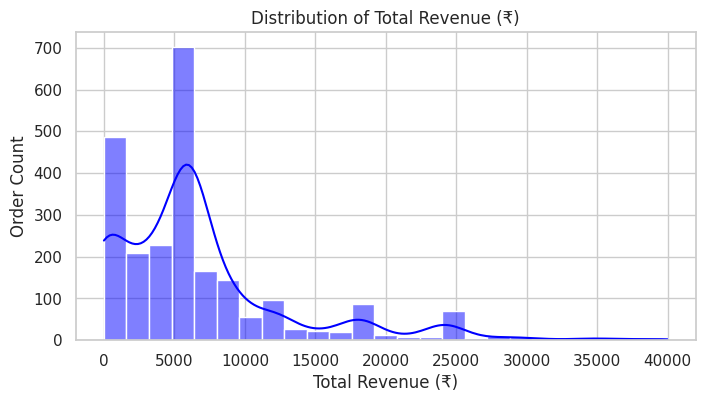

In [16]:
# 1. Total Revenue Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["Total_Revenue"], bins=25, kde=True, color="blue")
plt.title("Distribution of Total Revenue (₹)")
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Order Count")
plt.show()



**Revenue Distribution Takeaway:**
* Positively right-skewed distribution.
* Most orders concentrate below ₹10,000, while a smaller volume of larger-ticket purchases extends toward ₹40,000.

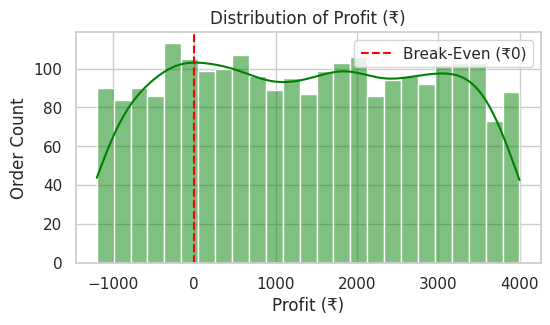

In [17]:
# 2. Profit Distribution with Loss Marker
plt.figure(figsize=(6, 3))
sns.histplot(df["Profit"], bins=25, kde=True, color="green")
plt.axvline(0, color="red", linestyle="--", label="Break-Even (₹0)")
plt.title("Distribution of Profit (₹)")
plt.xlabel("Profit (₹)")
plt.ylabel("Order Count")
plt.legend()
plt.show()

**Profit Distribution Takeaway:**
* Profit peaks at positive margins, averaging ~₹1,388
* The distribution extends left past the red line down to -₹1,199.32, proving that certain heavily discounted transactions result in net losses.

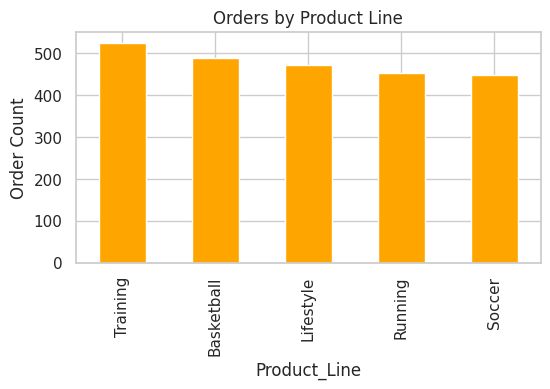

In [18]:
# 3. Product Line Order Frequencies
plt.figure(figsize=(6, 3))
df["Product_Line"].value_counts().plot(
    kind="bar", color="orange", title="Orders by Product Line"
)
plt.ylabel("Order Count")
plt.show()

**Product Line Distribution Takeaway:**
* Customer demand is evenly spread across all 5 lines (450 to 520 orders each).
* Training leads total order volume, followed closely by Basketball and Lifestyle.

## 3. Bivariate Analysis
We evaluate the relationship between two variables—specifically testing how escalating discounts impact profitability across sales channels, and summarizing sales performance by product line.

=== Category Performance Summary ===


,Orders,Total_Revenue,Average_Profit
Product_Line,,,
Basketball,489,3187952.64,1345.61
Lifestyle,472,3498835.23,1397.34
Running,452,2920441.49,1394.33
Soccer,448,3004362.44,1443.17
Training,525,3492029.67,1369.14


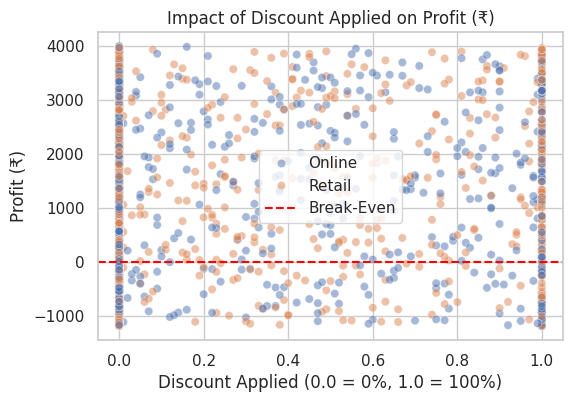

In [19]:
# Groupby aggregation across product categories
product_summary = df.groupby("Product_Line").agg(
    Orders=("Order_ID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Average_Profit=("Profit", "mean")
).round(2)

print("=== Category Performance Summary ===")
display(product_summary)

# Scatter plot: Discount depth vs Profit
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x="Discount_Applied",
    y="Profit",
    hue="Sales_Channel",
    alpha=0.5
)
plt.axhline(0, color="red", linestyle="--", label="Break-Even")
plt.title("Impact of Discount Applied on Profit (₹)")
plt.xlabel("Discount Applied (0.0 = 0%, 1.0 = 100%)")
plt.ylabel("Profit (₹)")
plt.legend()
plt.show()

**Key Takeaways:**
* **Margin Erosion:** Low discounts (0% to 20%) maintain stable margins; discounts above 50% systematically push orders below the red break-even line into negative profit.
* **Channel Performance:** Both Retail and Online channels display identical vulnerability to steep markdown losses.

## 4. Multivariate Analysis
We combine three dimensions simultaneously—Region, Product Line, and Profit—using a pivot table and heatmap matrix to identify geographic earning centers.

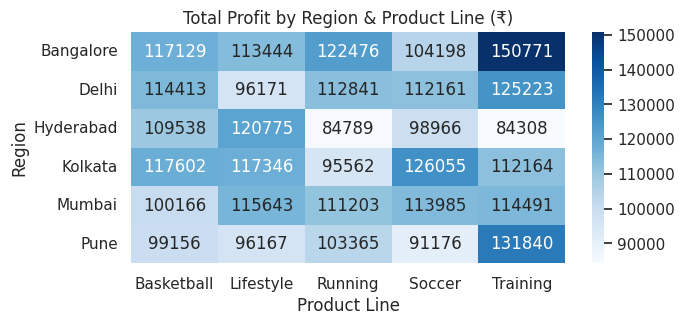

In [20]:
# Pivot Table: Total Profit across Region and Product Line
pivot_profit = df.pivot_table(
    values="Profit",
    index="Region",
    columns="Product_Line",
    aggfunc="sum"
).round(2)

plt.figure(figsize=(7, 3))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="Blues")
plt.title("Total Profit by Region & Product Line (₹)")
plt.xlabel("Product Line")
plt.ylabel("Region")
plt.show()

**Key Takeaways:**
* **Regional Contribution:** Highlights exactly which product categories drive the highest cumulative profit in each major metro hub.
* **Portfolio Health:** Darker cells represent core margin drivers, while lighter cells pinpoint underperforming product categories requiring promotional re-evaluation.

## 5. Correlation Analysis
We calculate the Pearson correlation matrix across numerical variables to quantify linear relationships between pricing, units sold, discounts, and margins.

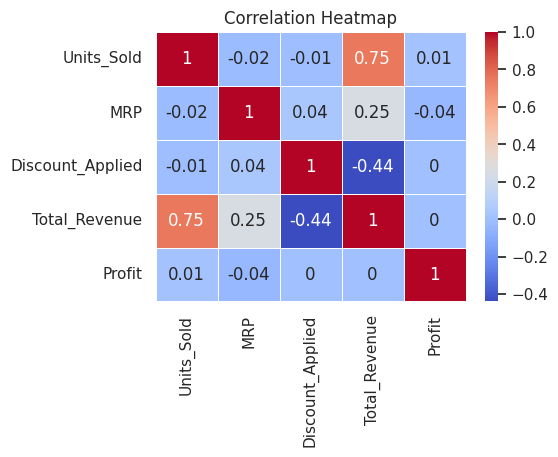

In [21]:
# Correlation matrix and heatmap
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(5, 3.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Key Takeaways:**
* **Revenue Drivers:** Total_Revenue exhibits strong positive correlation with both Units_Sold and MRP.
* **Discount Impact:** Discount_Applied displays a clear negative correlation with transaction profitability, confirming that steep promotional markdowns directly reduce realized margins.

# Phase 4: Data Visualizations

## Objective & Overview
Following the exploratory data analysis, this phase translates statistical summaries into visual business patterns using Matplotlib and Seaborn.

### Key Questions This Phase Addresses:
1. **Sales Channel Performance:** How does revenue split between Retail stores and Online platforms?
2. **Geographical Distribution:** Which Indian metro cities generate the largest order volume?
3. **Profitability & Losses:** Where do discounts trigger net losses across channels and product lines?
4. **Pricing & Demand Dynamics:** How do list price (MRP), order basket quantities, and customer segments impact overall business revenue?
5. **Regional Profit Opportunities:** Which product categories generate the highest cumulative profit in each major city?

/tmp/ipykernel_777/1058579373.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Sales_Channel", y="Total_Revenue", estimator=sum, ci=None, palette="Blues")
/tmp/ipykernel_777/1058579373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sales_Channel", y="Total_Revenue", estimator=sum, ci=None, palette="Blues")


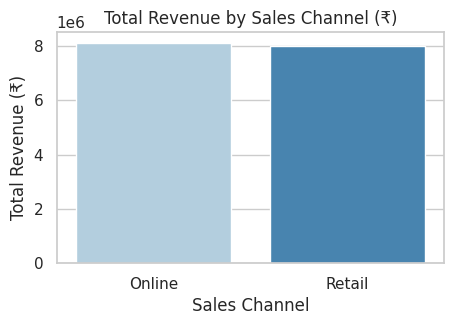

In [22]:
# Chart 1: Revenue by Sales Channel (Bar Plot)

plt.figure(figsize=(5, 3))
sns.barplot(data=df, x="Sales_Channel", y="Total_Revenue", estimator=sum, ci=None, palette="Blues")
plt.title("Total Revenue by Sales Channel (₹)")
plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue (₹)")
plt.show()

**Findings — Revenue by Sales Channel:**
* Total revenue is evenly split between **Retail** and **Online** channels.
* Neither sales channel dominates gross earnings, confirming a balanced omnichannel presence across physical stores and digital platforms.

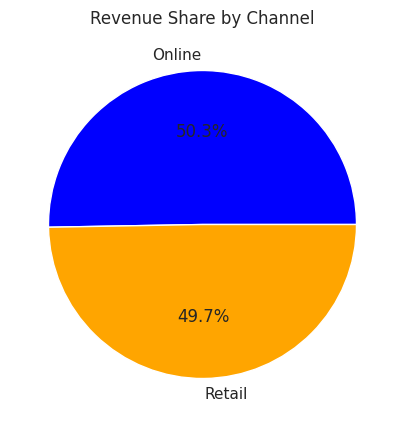

In [23]:
# Chart 2: Revenue Share by Channel (Pie Chart)

plt.figure(figsize=(5, 5))
df.groupby("Sales_Channel")["Total_Revenue"].sum().plot(
    kind="pie", autopct="%1.1f%%", colors=["blue", "orange"]
)
plt.title("Revenue Share by Channel")
plt.ylabel("")
plt.show()

**Findings — Channel Revenue Share:**
* Shows the exact percentage contribution of each channel to gross revenue.
* Confirms consumer demand is equally divided between in-store shopping and digital purchases.

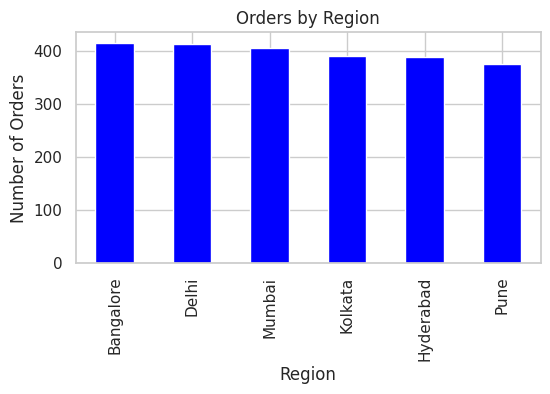

In [24]:
# Chart 3: Order Count by Region (Bar Plot)

plt.figure(figsize=(6, 3))
df["Region"].value_counts().plot(kind="bar", color="blue")
plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.show()

**Findings — Regional Demand:**
* **Bangalore**, **Delhi**, and **Mumbai** lead in order frequency, serving as primary retail hubs.
* **Kolkata**, **Hyderabad**, and **Pune** maintain steady secondary order volumes.

/tmp/ipykernel_777/2624726054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sales_Channel", y="Profit", palette="Set2")


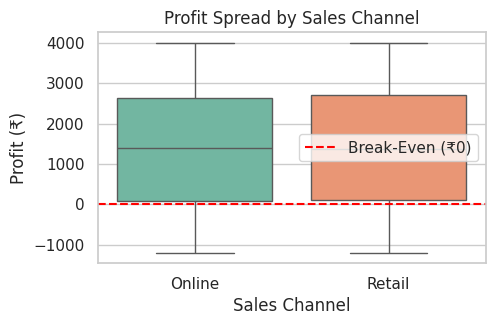

In [25]:
# Chart 4: Profit Spread by Sales Channel (Box Plot)

plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x="Sales_Channel", y="Profit", palette="Set2")
plt.axhline(0, color="red", linestyle="--", label="Break-Even (₹0)")
plt.title("Profit Spread by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit (₹)")
plt.legend()
plt.show()

**Findings — Channel Profitability & Losses:**
* Both channels maintain a stable positive median profit per order.
* The lower outliers extending past the red break-even line show that aggressive discounts generate net losses across both channels.

/tmp/ipykernel_777/566660896.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Product_Line", y="Profit", palette="Pastel1")


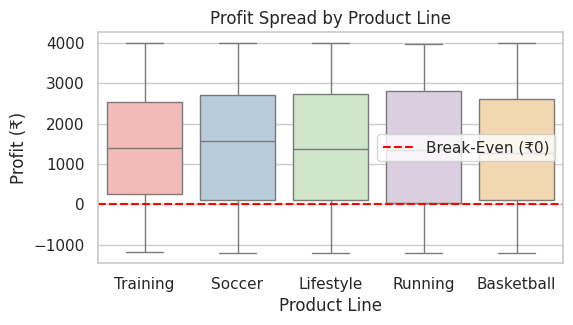

In [26]:
# Chart 5: Profit Spread by Product Line (Box Plot)

plt.figure(figsize=(6, 3))
sns.boxplot(data=df, x="Product_Line", y="Profit", palette="Pastel1")
plt.axhline(0, color="red", linestyle="--", label="Break-Even (₹0)")
plt.title("Profit Spread by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Profit (₹)")
plt.legend()
plt.show()

**Findings — Product Line Margins:**
* All five product categories maintain positive median profit margins.
* Outliers below the break-even line verify that every category is exposed to loss-making transactions when discounts are applied too deeply.

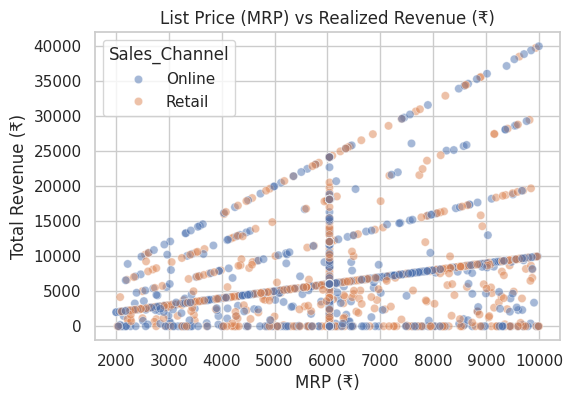

In [27]:
# Chart 6: MRP vs. Total Revenue (Scatter Plot)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="MRP", y="Total_Revenue", hue="Sales_Channel", alpha=0.5)
plt.title("List Price (MRP) vs Realized Revenue (₹)")
plt.xlabel("MRP (₹)")
plt.ylabel("Total Revenue (₹)")
plt.show()

**Findings — Pricing vs. Revenue Realization:**
* Footwear with higher base MRP translates directly into larger transaction revenue.
* Distinct upward bands reflect multi-unit basket orders (1, 2, 3, or 4 units) purchased at listed prices.

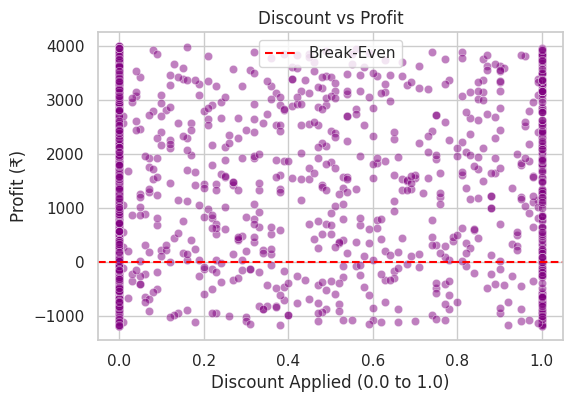

In [28]:
# Chart 7: Discount Applied vs. Profit (Scatter Plot)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Discount_Applied", y="Profit", color="purple", alpha=0.5)
plt.axhline(0, color="red", linestyle="--", label="Break-Even")
plt.title("Discount vs Profit")
plt.xlabel("Discount Applied (0.0 to 1.0)")
plt.ylabel("Profit (₹)")
plt.legend()
plt.show()

**Findings — The Loss Threshold:**
* Discounts up to 30%–40% generate healthy positive profits.
* Markdowns exceeding 50% systematically drop margins below the red break-even line, driving direct losses down to -₹1,199.32.

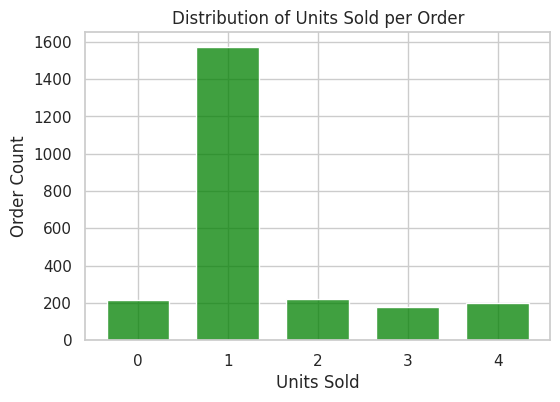

In [29]:
# Chart 8: Basket Size Distribution (Histogram)

plt.figure(figsize=(6, 4))
sns.histplot(df["Units_Sold"], bins=4, discrete=True, color="green", shrink=0.7)
plt.title("Distribution of Units Sold per Order")
plt.xlabel("Units Sold")
plt.ylabel("Order Count")
plt.show()

**Findings — Units Sold Distribution:**
* The vast majority of transactions consist of single-unit purchases (1 pair).
* Multi-unit transactions (2 to 4 pairs) occur less frequently, pointing to an opportunity for volume-based bundle incentives.

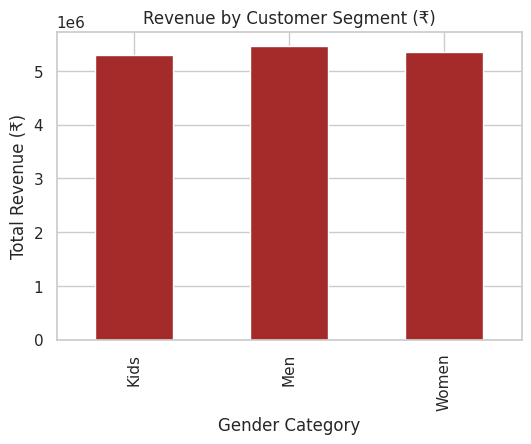

In [30]:
# Chart 9: Revenue by Gender Segment (Bar Plot)

plt.figure(figsize=(6, 4))
df.groupby("Gender_Category")["Total_Revenue"].sum().plot(kind="bar", color="brown")
plt.title("Revenue by Customer Segment (₹)")
plt.xlabel("Gender Category")
plt.ylabel("Total Revenue (₹)")
plt.show()

**Findings — Demographic Segments:**
* Revenue contribution is evenly distributed across **Men**, **Women**, and **Kids** segments.
* Confirms steady brand interest across customer demographics without relying entirely on a single group.

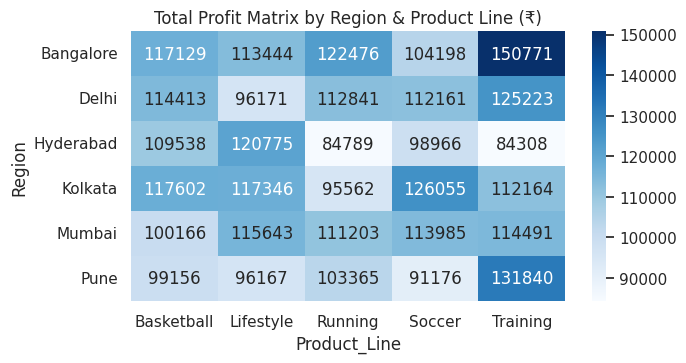

In [31]:
# Chart 10: Profit Heatmap by Region & Product Line (Heatmap)

plt.figure(figsize=(7, 3.5))
pivot_table = df.pivot_table(values="Profit", index="Region", columns="Product_Line", aggfunc="sum")
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Blues")
plt.title("Total Profit Matrix by Region & Product Line (₹)")
plt.show()

**Findings — Regional Profit Matrix:**
* Cross-analyzes Region, Product Line, and Total Profit in a single matrix.
* Darker cells identify key earning combinations (such as Training in Bangalore and Lifestyle in Delhi), helping guide localized inventory allocation.

# Phase 5: Insight Generation & Business Recommendations

### 1. Executive Summary & Core Insights
By building a complete data cleaning, analysis, and visualization pipeline across 2,386 verified Nike India retail records, this project uncovered the main factors driving revenue, regional demand, and net profit.

Balanced Sales Channels: Revenue is split evenly between online stores and physical retail shops, showing a healthy, balanced mix of digital and in-person buyers.

The Discount Trap: While big seasonal sales drive up order numbers, heavy discounts above 50% destroy profits, leading to direct net losses (dropping down to -₹1,199.32 per order).

Key City Markets: Major metro hubs—specifically Bangalore, Delhi, and Mumbai—generate the most orders and form the backbone of total earnings, while cities like Kolkata, Hyderabad, and Pune provide steady, reliable baseline demand.

Steady Product Demand: Customer demand is spread evenly across all five core product lines (Basketball, Lifestyle, Running, Soccer, and Training, with sales ranging tightly between 445 and 525 orders each), proving strong brand interest across all categories rather than relying on just one bestseller.

### 2. Key Patterns, Correlations & Anomalies
Pricing and Revenue: Higher list prices (MRP) lead directly to higher total revenue, especially when customers buy multiple items per order (1 to 4 pairs). However, unmanaged discounts completely wipe out this pricing advantage.

The 50% Loss Line: Orders with discounts between 0% and 40% keep healthy, steady positive profits. The financial tipping point happens right at the 50% mark, where reduced prices fail to cover basic costs, causing an immediate drop into net losses.

Top Regional Matches: Looking at regions and product lines together highlights standout performers—most notably Training gear in Bangalore and Lifestyle collections in Delhi—acting as our primary profit drivers.

### 3. Strategic Recommendations & Next Steps
To protect profit margins while growing market share across India, management should take these data-driven actions:

Set Discount Limits: Put a strict automated rule in place capping discounts at a maximum of 40% for both online and store channels to permanently stop loss-making sales (-₹1,199 losses).

Smart Stock Placement: Direct marketing budget and stock to high-performing city and product matches (focusing on Training gear in Bangalore and Lifestyle lines in Delhi).

Encourage Multi-Item Buying: Since most orders are single-item purchases, replace flat 50%+ clearance sales with smart bundle deals (like multi-item discounts) to safely increase the average order value.

Improve Data Entry at Stores: Fix data tracking gaps—like missing MRPs and unrecorded discounts found during our initial checks—by adding strict validation rules directly into store checkout systems.